In [7]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [16]:
#Define State
class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float
    category: str

In [18]:
def calculate_bmi(state: BMIState) -> BMIState:
    weight = state['weight_kg']
    height = state['height_m']
    bmi = weight / (height ** 2)
    state['bmi'] = round(bmi, 2)
    return state

def label_bmi(state: BMIState) -> BMIState:
    bmi = state['bmi']
    if bmi < 18.5:
        state['category'] = 'Underweight'
    elif 18.5 <= bmi < 24.9:
        state['category'] = 'Normal weight'
    elif 25 <= bmi < 29.9:
        state['category'] = 'Overweight'
    else:
        state['category'] = 'Obesity'
    return state

In [19]:
# Define the Graph
graph = StateGraph(BMIState)

#Add Nodes
graph.add_node('calculate bmi', calculate_bmi)
graph.add_node('label_bmi', label_bmi)

#Add Edges
graph.add_edge(START, 'calculate bmi')
graph.add_edge('calculate bmi', 'label_bmi')
graph.add_edge('label_bmi', END)

#Compile the Graph
workflow = graph.compile()

In [20]:
initial_state = {
    'weight_kg': 80,
    'height_m': 1.73,
    'bmi': 0.0,
    'category': ''
}
final_state = workflow.invoke(initial_state)

print("Final State:", final_state)

Final State: {'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'Overweight'}


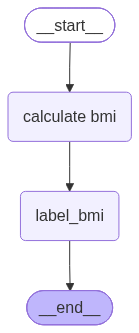

In [21]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())